# TRAS - C70 Quenched

### Mounting the google drive

In [1]:
# To begin, we import some libraries that we will need later.

# Some handy standard python libraries
import os

# The numpy library is very useful for many things
import numpy as np
import pandas as pd

# The pyplot module from matplotlib will allow us to plot things.
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from math import pi

In [2]:
# Connect (mount) your google drive as a virtual directory accessible by this python code.
from google.colab import drive         # Import the python module that allows you to access your google drive
rootpathdrive = '/content/drive'       # This will be the directory as which your google drive will be known
drive.mount(rootpathdrive)             # Now connect to this google drive.

# At first use it will ask you to click on a link, after which you should give permission
# for outside processes to access your google drive. A authorization code is generated which should be entered
#(this is explained in https://colab.research.google.com/notebooks/io.ipynb#scrollTo=XDg9OBaYqRMd).

Mounted at /content/drive


In [3]:
# # A good test to do is if you can see the contents of the directory in which you work on your google drive.
# # Here "My Drive" refers to the "root" of your google drive.
# # By default your notebook should be in a directory called Colab Notebooks.
# # This template assumes all files you want to read in are copied in the
# # same directory. Note the slash at the end of the first line.

# #==============================================================================================================
# #pathTRAS = rootpathdrive+'/'+'My Drive/Year 3 Lab/Pulsar/Crab_pulsar_template/' # Fin's Directory
# #pathTRAS = rootpathdrive+'/'+'My Drive/Year 3 Lab/Pulsar/CrabPulsar/Crab_pulsar_template' #Fin's 2
pathTRAS = rootpathdrive+'/'+'My Drive/Colab Notebooks/TRAS/C70_17Feb2026' #Sara's directory
# #==============================================================================================================

filelist = []
for (dirpath, dirnames, filenames) in os.walk(pathTRAS):
    filelist.extend(filenames)
    break
print (filelist)   # Show the contents of your working directory. At least your notebook should show up here.


['2026-02-17 15-16-40 TA BZC1.csv', '2026-02-17 15-28-18 TA BZC075.csv', '2026-02-17 15-38-54 TA BZC05.csv', '2026-02-17 15-50-22 TA BZC025.csv', '2026-02-17 16-00-17 TA BZC01.csv', '2026-02-17 15-16-40 TA BZC1_Bootstrap_Distribution.png', '2026-02-17 15-16-40 TA BZC1_signal_vs_time.png', '2026-02-17 15-28-18 TA BZC075_Bootstrap_Distribution.png', '2026-02-17 15-28-18 TA BZC075_signal_vs_time.png', '2026-02-17 15-38-54 TA BZC05_Bootstrap_Distribution.png', '2026-02-17 15-38-54 TA BZC05_signal_vs_time.png', '2026-02-17 15-50-22 TA BZC025_Bootstrap_Distribution.png', '2026-02-17 15-50-22 TA BZC025_signal_vs_time.png', '2026-02-17 16-00-17 TA BZC01_Bootstrap_Distribution.png', '2026-02-17 16-00-17 TA BZC01_signal_vs_time.png', 'SelfQuenching_SternVolmer.png', 'C70_Quench_24Feb2026.ipynb', 'Double_exp_C70_Quench_24Feb2026.ipynb']


## Loading and cleaning data
This step removes the negative bits before the exponential decay.

In [4]:
csv_title = '2026-02-17 16-00-17 TA BZC01.csv' #Modify this
clean_title = csv_title.replace(".csv", "")

df = pd.read_csv(
    os.path.join(pathTRAS, csv_title),
    sep=";",
    header=None,
    names=["time", "signal"]
)

df.head()

df = df.iloc[1:].reset_index(drop=True)
df = df.astype(float)

# index of maximum signal
idx_peak = df["signal"].idxmax()
df = df.loc[idx_peak:].reset_index(drop=True)


time = df["time"].to_numpy()
signal = df["signal"].to_numpy()

## Fitting an exponential

In [5]:
# Bi-exponential fit
def biexp_decay(t, A1, tau1, A2, tau2, C):
    return A1 * np.exp(-t / tau1) + A2 * np.exp(-t / tau2) + C

# Data
x = time
y = signal

# Initial guesses — split amplitude between two components, use different tau scales
A_init = (y.max() - y.min()) / 2
tau1_init = (x.max() - x.min()) / 10   # faster component
tau2_init = (x.max() - x.min()) / 2    # slower component
C_init = y.min()
p0 = [A_init, tau1_init, A_init, tau2_init, C_init]
bounds = ([-np.inf, 0, -np.inf, 0, -np.inf],
          [ np.inf, np.inf,  np.inf, np.inf,  np.inf])

# Fit
popt, pcov = curve_fit(biexp_decay, x, y, p0=p0, bounds=bounds)
A1, tau1, A2, tau2, C = popt
param_errors = np.sqrt(np.diag(pcov))
A1_err, tau1_err, A2_err, tau2_err, C_err = param_errors

# Residuals
y_fit_data = biexp_decay(x, *popt)
residuals = y - y_fit_data

# Bootstrapping — now collecting both taus
n_boot = 5000
tau1_boot, tau2_boot = [], []

for _ in range(n_boot):
    resampled_residuals = np.random.choice(residuals, size=len(residuals), replace=True)
    y_boot = y_fit_data + resampled_residuals

    try:
        popt_boot, _ = curve_fit(biexp_decay, x, y_boot, p0=popt, bounds=bounds)
        tau1_boot.append(popt_boot[1])
        tau2_boot.append(popt_boot[3])
    except RuntimeError:
        continue

tau1_boot = np.array(tau1_boot)
tau2_boot = np.array(tau2_boot)

# Bootstrap statistics
for label, tau_val, tau_b in [("tau1", tau1, tau1_boot), ("tau2", tau2, tau2_boot)]:
    std = np.std(tau_b)
    ci_lo, ci_hi = np.percentile(tau_b, [2.5, 97.5])
    print(f"Best-fit {label} = {tau_val:.3f} ns")
    print(f"Bootstrap SE      = {std:.3f} ns")
    print(f"95% CI            = [{ci_lo:.3f}, {ci_hi:.3f}] ns\n")

Best-fit tau1 = 881.557 ns
Bootstrap SE      = 20.380 ns
95% CI            = [814.221, 908.455] ns

Best-fit tau2 = 890.558 ns
Bootstrap SE      = 795574.804 ns
95% CI            = [847.922, 932.556] ns



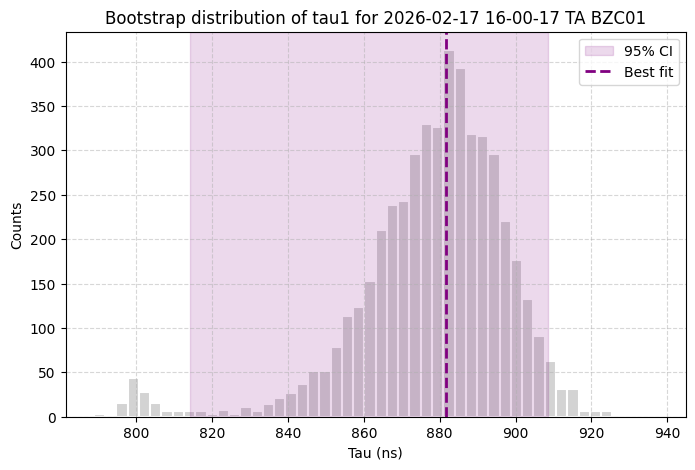

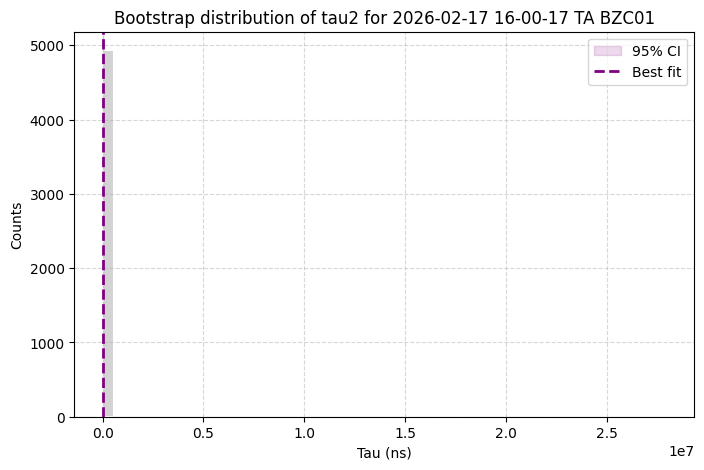

In [6]:
for label, tau_val, tau_b in [("tau1", tau1, tau1_boot), ("tau2", tau2, tau2_boot)]:
    ci_lo, ci_hi = np.percentile(tau_b, [2.5, 97.5])

    plt.figure(figsize=(8, 5))
    plt.hist(tau_b, bins=50, facecolor='#D3D3D3', edgecolor='white', linewidth=1.5)
    plt.axvspan(ci_lo, ci_hi, alpha=0.15, color='purple', label='95% CI')
    plt.axvline(tau_val, color='purple', linestyle='--', linewidth=2, label='Best fit')
    plt.xlabel("Tau (ns)")
    plt.ylabel("Counts")
    plt.title(f"Bootstrap distribution of {label} for {clean_title}")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.savefig(
        f"/content/drive/MyDrive/Colab Notebooks/TRAS/C70_17Feb2026/{clean_title}_{label}_Bootstrap_Distribution.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

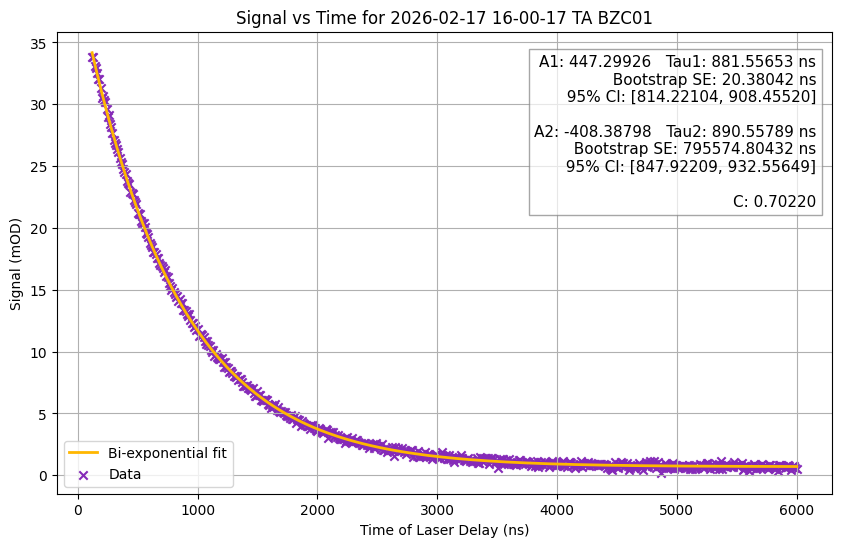


=== Stern–Volmer preparation values ===
Concentration (you fill manually per sample): [insert here]
Tau1 value (ns): 881.55653
Tau1 bootstrap SE (ns): 20.38042
Tau1 95% CI: [814.22104, 908.45520]

Tau2 value (ns): 890.55789
Tau2 bootstrap SE (ns): 795574.80432
Tau2 95% CI: [847.92209, 932.55649]


In [8]:
# --- Create fine x-axis for smooth fitted curve ---
x_fit = np.linspace(x.min(), x.max(), 1000)
y_fit = biexp_decay(x_fit, *popt)

plt.figure(figsize=(10, 6))

# Plot the bi-exponential fit
plt.plot(x_fit, y_fit, color='#FFB700', linewidth=2, label='Bi-exponential fit')

# Plot the data points
plt.scatter(x, y, marker='x', color='#852AB8', label='Data')

# Title and labels
plt.title(f'Signal vs Time for {clean_title}')
plt.xlabel('Time of Laser Delay (ns)')
plt.ylabel('Signal (mOD)')

# Compute CI for both taus
ci1_lo, ci1_hi = np.percentile(tau1_boot, [2.5, 97.5])
ci2_lo, ci2_hi = np.percentile(tau2_boot, [2.5, 97.5])
tau1_std = np.std(tau1_boot)
tau2_std = np.std(tau2_boot)

# Add best-fit parameters as text
plt.text(
    0.98, 0.95,
    f'A1: {A1:.5f}   Tau1: {tau1:.5f} ns\n'
    f'  Bootstrap SE: {tau1_std:.5f} ns\n'
    f'  95% CI: [{ci1_lo:.5f}, {ci1_hi:.5f}]\n\n'
    f'A2: {A2:.5f}   Tau2: {tau2:.5f} ns\n'
    f'  Bootstrap SE: {tau2_std:.5f} ns\n'
    f'  95% CI: [{ci2_lo:.5f}, {ci2_hi:.5f}]\n\n'
    f'C: {C:.5f}',
    transform=plt.gca().transAxes,
    ha='right',
    va='top',
    fontsize=11,
    color='black',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
)

plt.legend()
plt.grid(True)

# Save figure
plt.savefig(
    f"/content/drive/MyDrive/Colab Notebooks/TRAS/C70_17Feb2026/{clean_title}_signal_vs_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# --- Output values for Stern-Volmer preparation ---
print("\n=== Stern–Volmer preparation values ===")
print(f"Concentration (you fill manually per sample): [insert here]")
print(f"Tau1 value (ns): {tau1:.5f}")
print(f"Tau1 bootstrap SE (ns): {tau1_std:.5f}")
print(f"Tau1 95% CI: [{ci1_lo:.5f}, {ci1_hi:.5f}]")
print(f"\nTau2 value (ns): {tau2:.5f}")
print(f"Tau2 bootstrap SE (ns): {tau2_std:.5f}")
print(f"Tau2 95% CI: [{ci2_lo:.5f}, {ci2_hi:.5f}]")

# Values Obtained

=== Stern–Volmer preparation values ===
Concentration BZC1: [insert here]
Tau value (ns): 467.37783
Tau bootstrap SE (ns): 1.60444
Tau 95% CI low (ns): 464.25428
Tau 95% CI high (ns): 470.52153


=== Stern–Volmer preparation values ===
Concentration BZC075: [insert here]
Tau value (ns): 498.67187
Tau bootstrap SE (ns): 1.44686
Tau 95% CI low (ns): 495.84387
Tau 95% CI high (ns): 501.4426

=== Stern–Volmer preparation values ===
Concentration BZC05: [insert here]
Tau value (ns): 608.80600
Tau bootstrap SE (ns): 1.29290
Tau 95% CI low (ns): 606.30114
Tau 95% CI high (ns): 611.36303

=== Stern–Volmer preparation values ===
Concentration BZC025: [insert here]
Tau value (ns): 688.46917
Tau bootstrap SE (ns): 1.58258
Tau 95% CI low (ns): 685.31760
Tau 95% CI high (ns): 691.53833

=== Stern–Volmer preparation values ===
Concentration BZC01: [insert here]
Tau value (ns): 789.54620
Tau bootstrap SE (ns): 1.48348
Tau 95% CI low (ns): 786.68959
Tau 95% CI high (ns): 792.44233

In [ ]:
unc_from_base = 0.1**2
base2 = np.array([1, 0.75, 0.5, 0.25, 0.1])
solvent = np.array([1e-12, 0.25, 0.5, 0.75, 0.9])


conc_err = np.sqrt(
    unc_from_base +
    (0.1/base2)**2 +
    (0.1/solvent)**2
)

conc_err[0] = np.sqrt(2)/10
print(conc_err)



## Stern Volmer plot
Described on page 22 of the physical manual, gradient gives k_q

In [ ]:
# # # Array prep
# Concentrations (BZC1 → 1 mM … BZ01 → 0.1 mM)
concentrations = np.array([1, 0.75, 0.5, 0.25, 0.1])
tau_values = np.array([467.37783, 498.67187, 608.80600, 688.46917, 789.54620])
tau_std_values = np.array([1.60444, 1.44686, 1.29290,1.58258, 1.48348]) #Bootstrap errors


# Tau 95% CI low/high (ns)
tau_CI_low = np.array([464.25428, 495.84387, 606.30114 , 685.31760, 786.68959])
tau_CI_high = np.array([470.52153, 501.4426,  611.36303,  691.53833, 792.44233])


#k_app = 1 / tau
k_app = 1 / tau_values  # units 1/ns
k_app_SE = tau_std_values / (tau_values**2)  # propagate SE
k_app_CI_low = 1 / tau_CI_high  # lower bound for 1/tau
k_app_CI_high = 1 / tau_CI_low  # upper bound for 1/tau


#Bootstrapped derived slope
# Simple linear fit for SV slope
coeff = np.polyfit(concentrations, k_app, 1)
k_sv_slope = coeff[0]  # slope = Ksv
intercept = coeff[1]

# Optional: calculate gradient uncertainty via simple bootstrap (propagating k_app_CI)
# We'll just estimate ± from the CI ranges roughly
k_app_CI_width = k_app_CI_high - k_app_CI_low
# rough approximation of slope uncertainty
k_sv_slope_error = np.sqrt(np.sum((k_app_CI_width / (concentrations.max() - concentrations.min()))**2))

conc_err = [0.14142136, 0.43333333, 0.3,        0.43333333, 1.01111111]
#Plotting
plt.figure(figsize=(10, 6))

print(f"Stern–Volmer slope (Ksv): {k_sv_slope:.5e} 1/ns·mM ± {k_sv_slope_error:.5e}")
print(f"Intercept: {intercept:.5e}")

# Plotting (same as before)
plt.figure(figsize=(10, 6))

plt.scatter(concentrations, k_app, color='#852AB8', label='Bootstrap mean', zorder=5)
plt.errorbar(
    concentrations,
    k_app,
    #xerr=conc_err,
    yerr=[k_app - k_app_CI_low, k_app_CI_high - k_app],
    fmt='o',
    color='#852AB8',
    capsize=5,
    label='95% CI',
    zorder=4
)

x_fit = np.linspace(concentrations.min(), concentrations.max(), 100)
plt.plot(x_fit, np.polyval(coeff, x_fit), color='#FFB700',
         label=f'Gradient: k_q, Linear Fit (Ksv ≈ {k_sv_slope:.3e} ± {k_sv_slope_error:.3e}) 1/ns·mMol')

plt.xlabel("Concentration (mMol)")
plt.ylabel("k_app (1/ns)")
plt.title("Stern–Volmer Plot (Self-Quenching) with Bootstrap Uncertainty")
plt.grid(True)
plt.legend()

# Save figure
plt.savefig(
    f"/content/drive/MyDrive/Colab Notebooks/TRAS/C70_17Feb2026/SelfQuenching_SternVolmer.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

